<a href="https://colab.research.google.com/github/GabrielLobaton18/Pred_Com_De_Casa/blob/main/Predicci%C3%B3n_de_compra_de_casas_CGML_Redes_Neuronales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Comenzamos con poniendo las configuraciones iniciales necesarias

In [1]:
#como siempre instalamos lo usual, lo que seguramente necesitaremos
%pip install -q tensorflow
%pip install -q mlflow
%pip install -q pandas
%pip install -q matplotlib
%pip install -q scikit-learn
%pip install -q kaggle
%pip install -q dagshub


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 85.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 87.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.5/879.5 kB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [2]:
#reciclamos las importaciones del código pásado por si algo hace falta
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import mlflow
import dagshub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
import zipfile
import shutil
from google.colab import files, drive

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [3]:
dagshub.init(repo_owner='GabrielLobaton18', repo_name='Pred_Com_De_Casa', mlflow=True)
with mlflow.start_run():
  # Your training code here...
  mlflow.log_metric('accuracy', 42)
  mlflow.log_param('Param name', 'Value')

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=56a25657-1c7c-4fa8-9f54-fd6602df844c&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=88e76cd82902d764a15d22848c13689ccc29d807b51f3bd6e1cc4051abf99c69




Accessing as GabrielLobaton18

Initialized MLflow to track repo "GabrielLobaton18/Pred_Com_De_Casa"

Repository GabrielLobaton18/Pred_Com_De_Casa initialized!

🏃 View run loud-elk-507 at: https://dagshub.com/GabrielLobaton18/Pred_Com_De_Casa.mlflow/#/experiments/0/runs/c279a460f95147668e664eb2f52ab29b
🧪 View experiment at: https://dagshub.com/GabrielLobaton18/Pred_Com_De_Casa.mlflow/#/experiments/0


Descargamos

In [4]:
# Configurar las variables de entorno de Kaggle
os.environ['KAGGLE_USERNAME'] = 'Gabriel Lobatón'
os.environ['KAGGLE_KEY'] = 'KGAT_da409035364bf1d526a25d9cf4e6e310'

In [5]:
# Descargamos el dataset de compra de casas
!kaggle datasets download -d mohankrishnathalla/global-house-purchase-decision-dataset

# Descomprimimos en una carpeta específica
!unzip -q global-house-purchase-decision-dataset.zip -d /content/house_dataset

# Verificamos la descarga
!ls /content/house_dataset

Dataset URL: https://www.kaggle.com/datasets/mohankrishnathalla/global-house-purchase-decision-dataset
License(s): CC0-1.0
100% 7.42M/7.42M [00:01<00:00, 4.57MB/s]

global_house_purchase_dataset.csv


In [6]:
# Cargamos el archivo de atributos
attr_df = pd.read_csv('/content/global-house-purchase-decision-dataset.zip')

# Mostramos las primeras filas
print(attr_df.head())

# Visualizamos la forma del dataframe
print("Dimensiones:", attr_df.shape)

   property_id       country          city property_type furnishing_status  \
0            1        France     Marseille     Farmhouse    Semi-Furnished   
1            2  South Africa     Cape Town     Apartment    Semi-Furnished   
2            3  South Africa  Johannesburg     Farmhouse    Semi-Furnished   
3            4       Germany     Frankfurt     Farmhouse    Semi-Furnished   
4            5  South Africa  Johannesburg     Townhouse   Fully-Furnished   

   property_size_sqft    price  constructed_year  previous_owners  rooms  ...  \
0                 991   412935              1989                6      6  ...   
1                1244   224538              1990                4      8  ...   
2                4152   745104              2019                5      2  ...   
3                3714  1110959              2008                1      3  ...   
4                 531    99041              2007                6      3  ...   

   customer_salary  loan_amount  loan_tenure

ahora pasaremos el texto como variable categorica y normalizaremos la variables númericas

In [7]:
#Copiamos del dataframe original para que no lo perdamos
df_clean = attr_df.copy()

# Eliminamos la  columna 'property_id' ya que ese dato en principio no debería de influir en la desición de si comprarla o no
if 'property_id' in df_clean.columns:
    df_clean = df_clean.drop('property_id', axis=1)

#Identificamos columnas categóricas y numéricas
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()

#La variable objetivo 'decision' debe ir aparte es la más importante, así que la quitamos de las numéricas
if 'decision' in numerical_cols:
    numerical_cols.remove('decision')

#confirmamos que todo ah salido bien hasta ahí
print("Columnas categóricas:", categorical_cols)
print("Columnas numéricas (predictoras):", numerical_cols)
print("Variable objetivo: decision")

Columnas categóricas: ['country', 'city', 'property_type', 'furnishing_status']
Columnas numéricas (predictoras): ['property_size_sqft', 'price', 'constructed_year', 'previous_owners', 'rooms', 'bathrooms', 'garage', 'garden', 'crime_cases_reported', 'legal_cases_on_property', 'customer_salary', 'loan_amount', 'loan_tenure_years', 'monthly_expenses', 'down_payment', 'emi_to_income_ratio', 'satisfaction_score', 'neighbourhood_rating', 'connectivity_score']
Variable objetivo: decision


In [8]:
#Aplicamos un  One-Hot Encoding a las variables categóricas
'''usamos pandas get_dummies, que crea nuevas columnas para cada categoría'''
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=False)

# Separarmos  características (X) y variable objetivo (y)
X = df_encoded.drop('decision', axis=1)
y = df_encoded['decision']

""""Normalizamos las variables númericas, sin embargo solo las que requieren de normalización
Las columnas que ya están entre  0 y 1, no necesitan normalización, sú significa es diferente
las primeras podemos entenderla como una distribución normal de probabilidades y las otras como una clasificación binaria"""

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

print("Dimensiones finales X:", X.shape)
print("Primeras filas de X:\n", X.head())

Dimensiones finales X: (200000, 81)
Primeras filas de X:
    property_size_sqft     price  constructed_year  previous_owners     rooms  \
0           -1.366521 -0.974224         -0.134518         1.497673  0.647371   
1           -1.209701 -1.202955         -0.080446         0.498768  1.518579   
2            0.592795 -0.570940          1.487629         0.998220 -1.095045   
3            0.321305 -0.126759          0.892842        -0.999589 -0.659441   
4           -1.651648 -1.355320          0.838770         1.497673 -0.659441   

   bathrooms    garage   garden  crime_cases_reported  \
0  -0.412846  1.001301  0.99957             -0.193249   
1   2.846333  1.001301  0.99957             -0.193249   
2  -0.956042  1.001301  0.99957             -1.036894   
3   0.130351 -0.998701  0.99957             -1.036894   
4   0.130351  1.001301  0.99957              1.494040   

   legal_cases_on_property  ...  city_Vancouver  property_type_Apartment  \
0                -0.575687  ...           

In [9]:
#Separamos validación (10% del total)
X_temp, X_val, y_temp, y_val = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

#Calculamos cuántas muestras corresponden a prueba (20% del total original)
# sobre el conjunto temporal (90% del total)
total_original = len(X)
tam_prueba = int(0.2 * total_original)   # 20% de 200000 = 40000
tam_temp = len(X_temp)                    # 180000

# Asegurar que tam_prueba no supere tam_temp
tam_prueba = min(tam_prueba, tam_temp)

#Separamos prueba y entrenamiento
X_test, X_train, y_test, y_train = train_test_split(
    X_temp, y_temp, test_size=tam_temp - tam_prueba,   # el resto para entrenamiento
    random_state=42, stratify=y_temp
)

print(f"Entrenamiento: {len(X_train)} muestras ({len(X_train)/total_original:.0%})")
print(f"Prueba:       {len(X_test)} muestras ({len(X_test)/total_original:.0%})")
print(f"Validación:   {len(X_val)} muestras ({len(X_val)/total_original:.0%})")

Entrenamiento: 140000 muestras (70%)
Prueba:       40000 muestras (20%)
Validación:   20000 muestras (10%)


decidí usar optuna aunque fuera más tardado para encontrar la mejor arquitectura en lugar de plantera una desde 0

In [10]:
#Instalamos e importamos Optuna
!pip install -q optuna
!pip install optuna-integration[tfkeras]
import optuna
from optuna.integration import TFKerasPruningCallback
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import layers, Model, Sequential, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Dropout
import mlflow
import matplotlib.pyplot as plt
import numpy as np

print("Optuna versión:", optuna.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 10.8 MB/s eta 0:00:00
Optuna versión: 4.8.0


In [11]:
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, RMSprop, SGD

def create_model(trial, input_dim):
    n_layers = trial.suggest_int('n_layers', 1, 5)

    units_per_layer = []
    for i in range(n_layers):
        units = trial.suggest_int(f'units_{i}', 16, 512, step=16)
        units_per_layer.append(units)

    dropout_rate = trial.suggest_float('dropout_rate', 0.2, 0.5, step=0.05)
    activation = trial.suggest_categorical('activation', ['relu', 'tanh'])
    optimizer_name = trial.suggest_categorical('optimizer', ['adam', 'rmsprop', 'sgd'])
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-2, log=True)

    model = Sequential()
    model.add(Input(shape=(input_dim,)))
    for units in units_per_layer:
        model.add(Dense(units, activation=activation))
        model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation='sigmoid'))

    if optimizer_name == 'adam':
        optimizer = Adam(learning_rate=learning_rate)
    elif optimizer_name == 'rmsprop':
        optimizer = RMSprop(learning_rate=learning_rate)
    else:
        optimizer = SGD(learning_rate=learning_rate)

    model.compile(optimizer=optimizer,
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

In [12]:
def objective(trial):
    input_dim = X_train.shape[1]
    model = create_model(trial, input_dim)

    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])

    early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
    pruning_callback = TFKerasPruningCallback(trial, monitor='val_accuracy')

    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=50,
        batch_size=batch_size,
        callbacks=[early_stop, pruning_callback],
        verbose=0
    )

    val_acc = max(history.history['val_accuracy'])

    with mlflow.start_run(run_name=f"trial_{trial.number}", nested=True):
        mlflow.log_params(trial.params)
        mlflow.log_metric('val_accuracy', val_acc)
        mlflow.keras.log_model(model, "model")

    return val_acc

In [ ]:
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=25, show_progress_bar=True)

print(study.best_params)
print(study.best_value)

[I 2026-05-08 03:53:49,390] A new study created in memory with name: no-name-17c2701b-c140-46de-b994-346897d5eab4


  0%|          | 0/25 [00:00<?, ?it/s]

2026/05/08 03:56:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 03:56:27 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


🏃 View run trial_0 at: https://dagshub.com/GabrielLobaton18/Pred_Com_De_Casa.mlflow/#/experiments/0/runs/bfe90fddbf4a4108b9d6c303458a65e3
🧪 View experiment at: https://dagshub.com/GabrielLobaton18/Pred_Com_De_Casa.mlflow/#/experiments/0
[I 2026-05-08 03:56:44,212] Trial 0 finished with value: 0.9990749955177307 and parameters: {'n_layers': 2, 'units_0': 496, 'units_1': 384, 'dropout_rate': 0.4, 'activation': 'relu', 'optimizer': 'rmsprop', 'learning_rate': 0.001331121608073689, 'batch_size': 64}. Best is trial 0 with value: 0.9990749955177307.


2026/05/08 03:59:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 03:59:33 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


...

🏃 View run trial_11 at: https://dagshub.com/GabrielLobaton18/Pred_Com_De_Casa.mlflow/#/experiments/0/runs/3c23cd8cac6e41eba64b4a9c204633c5
🧪 View experiment at: https://dagshub.com/GabrielLobaton18/Pred_Com_De_Casa.mlflow/#/experiments/0
[I 2026-05-08 04:29:37,993] Trial 11 finished with value: 0.9987499713897705 and parameters: {'n_layers': 3, 'units_0': 496, 'units_1': 368, 'units_2': 304, 'dropout_rate': 0.35000000000000003, 'activation': 'relu', 'optimizer': 'adam', 'learning_rate': 0.0014093366800945984, 'batch_size': 64}. Best is trial 4 with value: 0.9991250038146973.
[I 2026-05-08 04:30:01,627] Trial 12 pruned. Trial was pruned at epoch 1.


2026/05/08 04:31:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 04:31:32 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


🏃 View run trial_13 at: https://dagshub.com/GabrielLobaton18/Pred_Com_De_Casa.mlflow/#/experiments/0/runs/8a8f0bb58c1f40c88746b1701c99d695
🧪 View experiment at: https://dagshub.com/GabrielLobaton18/Pred_Com_De_Casa.mlflow/#/experiments/0
[I 2026-05-08 04:31:46,906] Trial 13 finished with value: 0.9991000294685364 and parameters: {'n_layers': 3, 'units_0': 384, 'units_1': 256, 'units_2': 496, 'dropout_rate': 0.35000000000000003, 'activation': 'relu', 'optimizer': 'adam', 'learning_rate': 0.0003812973132152538, 'batch_size': 64}. Best is trial 4 with value: 0.9991250038146973.
[I 2026-05-08 04:32:03,091] Trial 14 pruned. Trial was pruned at epoch 0.


2026/05/08 04:33:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 04:33:43 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


🏃 View run trial_15 at: https://dagshub.com/GabrielLobaton18/Pred_Com_De_Casa.mlflow/#/experiments/0/runs/cbfcd6c78a9c4f32b2946eb8c27d5da1
🧪 View experiment at: https://dagshub.com/GabrielLobaton18/Pred_Com_De_Casa.mlflow/#/experiments/0
[I 2026-05-08 04:33:55,723] Trial 15 finished with value: 0.998924970626831 and parameters: {'n_layers': 3, 'units_0': 320, 'units_1': 224, 'units_2': 512, 'dropout_rate': 0.35000000000000003, 'activation': 'relu', 'optimizer': 'adam', 'learning_rate': 0.000366083974233816, 'batch_size': 64}. Best is trial 4 with value: 0.9991250038146973.
[I 2026-05-08 04:34:06,683] Trial 16 pruned. Trial was pruned at epoch 0.
[I 2026-05-08 04:34:23,580] Trial 17 pruned. Trial was pruned at epoch 0.
[I 2026-05-08 04:34:39,098] Trial 18 pruned. Trial was pruned at epoch 0.
[I 2026-05-08 04:34:59,196] Trial 19 pruned. Trial was pruned at epoch 2.
[I 2026-05-08 04:35:13,518] Trial 20 pruned. Trial was pruned at epoch 0.
[I 2026-05-08 04:35:32,918] Trial 21 pruned. Trial

In [17]:
from mlflow.tracking import MlflowClient

dagshub.init(repo_owner='GabrielLobaton18', repo_name='Pred_Com_De_Casa', mlflow=True)

client = MlflowClient()
experiment = client.get_experiment_by_name("Pred_Com_De_Casa")
if experiment is None:
    experiment = client.get_experiment(0)


runs = client.search_runs(experiment.experiment_id, filter_string="tags.mlflow.runName LIKE 'trial_%'")
best_val_acc = -1
best_params = None
best_run_id = None

for run in runs:
    val_acc = run.data.metrics.get('val_accuracy')
    if val_acc is not None and val_acc > best_val_acc:
        best_val_acc = val_acc
        best_params = run.data.params
        best_run_id = run.info.run_id

print("Mejor precisión en prueba (val_accuracy) encontrada:", best_val_acc)
print("Mejores hiperparámetros:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

Initialized MLflow to track repo "GabrielLobaton18/Pred_Com_De_Casa"

Repository GabrielLobaton18/Pred_Com_De_Casa initialized!

Mejor precisión en prueba (val_accuracy) encontrada: 0.9991250038146973
Mejores hiperparámetros:
  n_layers: 5
  units_0: 320
  units_1: 480
  units_2: 48
  units_3: 112
  units_4: 32
  dropout_rate: 0.30000000000000004
  activation: relu
  optimizer: adam
  learning_rate: 0.00042470585622618684
  batch_size: 64


In [20]:
# Convertimos los parámetros a tipos correctos
n_layers = int(best_params['n_layers'])
units_per_layer = [int(best_params[f'units_{i}']) for i in range(n_layers)]
dropout_rate = float(best_params['dropout_rate'])
activation = best_params['activation']
optimizer_name = best_params['optimizer']
learning_rate = float(best_params['learning_rate'])
batch_size_final = int(best_params.get('batch_size', 64))

input_dim = X_train.shape[1]

model_final = Sequential()
model_final.add(Input(shape=(input_dim,)))
for units in units_per_layer:
    model_final.add(Dense(units, activation=activation))
    model_final.add(Dropout(dropout_rate))
model_final.add(Dense(1, activation='sigmoid'))

#Seleccionamos el optimizador
if optimizer_name == 'adam':
    optimizer = Adam(learning_rate=learning_rate)
elif optimizer_name == 'rmsprop':
    optimizer = RMSprop(learning_rate=learning_rate)
else:
    optimizer = SGD(learning_rate=learning_rate)

model_final.compile(optimizer=optimizer,
                    loss='binary_crossentropy',
                    metrics=['accuracy'])
model_final.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 320)            │        26,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 320)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 480)            │       154,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 480)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 48)             │        23,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 112)            │         5,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 112)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         3,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,545 (830.25 KB)

 Trainable params: 212,545 (830.25 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)

history_final = model_final.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=batch_size_final,
    callbacks=[early_stop],
    verbose=1
)

#Evaluamos en la validación
val_loss, val_acc = model_final.evaluate(X_val, y_val, verbose=0)
print(f"\n Precisión en conjunto de VALIDACIÓN: {val_acc:.4f}")

#Registramos este modelo final en MLflow
with mlflow.start_run(run_name="modelo_final_optuna"):
    mlflow.log_params(best_params)
    mlflow.log_metric('test_accuracy', max(history_final.history['val_accuracy']))
    mlflow.log_metric('validation_accuracy', val_acc)
    mlflow.keras.log_model(model_final, "modelo_final")

#Guardamos en Drive
model_final.save('/content/drive/MyDrive/house_purchase_final_model.h5')
print("Modelo guardado.")

Epoch 1/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.9628 - loss: 0.0876 - val_accuracy: 0.9976 - val_loss: 0.0078
Epoch 2/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9949 - loss: 0.0132 - val_accuracy: 0.9980 - val_loss: 0.0047
Epoch 3/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9969 - loss: 0.0080 - val_accuracy: 0.9985 - val_loss: 0.0036
Epoch 4/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9977 - loss: 0.0064 - val_accuracy: 0.9978 - val_loss: 0.0050
Epoch 5/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9981 - loss: 0.0051 - val_accuracy: 0.9986 - val_loss: 0.0034
Epoch 6/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9982 - loss: 0.0049 - val_accuracy: 0.9985 - val_loss: 0.0033
Epoch 7/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9985 - loss: 0.0043 - val_accuracy: 0.9983 - val_loss: 0.0035
Epoch 8/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9987 - loss:

2026/05/09 00:29:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/09 00:29:52 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


🏃 View run modelo_final_optuna at: https://dagshub.com/GabrielLobaton18/Pred_Com_De_Casa.mlflow/#/experiments/0/runs/4dbf9e3d073d4aa895c5d663d34b57a4
🧪 View experiment at: https://dagshub.com/GabrielLobaton18/Pred_Com_De_Casa.mlflow/#/experiments/0


Modelo guardado.


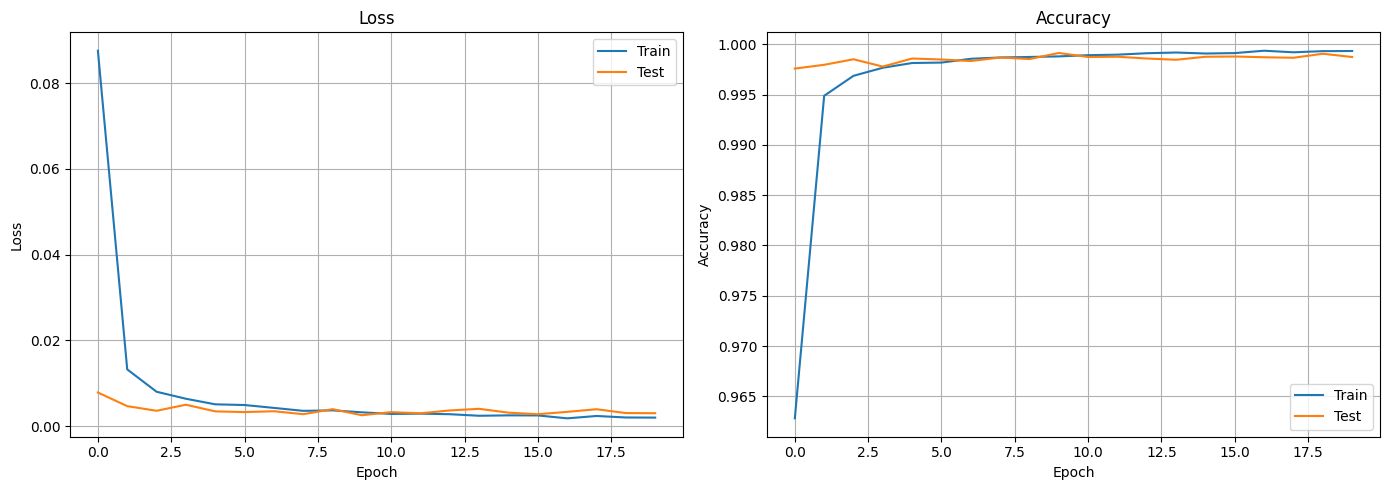

In [22]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history_final.history['loss'], label='Train')
plt.plot(history_final.history['val_loss'], label='Test')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history_final.history['accuracy'], label='Train')
plt.plot(history_final.history['val_accuracy'], label='Test')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('curvas_finales.png')
plt.show()

Finalmente aplicamos al conjunto de válidación para ver como quedó

In [23]:
#Evaluamos una única vez con el conjunto de validación. (para no hacer trampa)
val_loss, val_accuracy = model_final.evaluate(X_val, y_val, verbose=0)
print(f"🔍 Precisión en conjunto de VALIDACIÓN: {val_accuracy:.4f}")
print(f"🔍 Pérdida en validación: {val_loss:.4f}")

#Registramos en MLflow
with mlflow.start_run(run_name="evaluacion_final_validacion"):
    mlflow.log_metric("validation_accuracy", val_accuracy)
    mlflow.log_metric("validation_loss", val_loss)

🔍 Precisión en conjunto de VALIDACIÓN: 0.9988
🔍 Pérdida en validación: 0.0030
🏃 View run evaluacion_final_validacion at: https://dagshub.com/GabrielLobaton18/Pred_Com_De_Casa.mlflow/#/experiments/0/runs/6673582737c64b4c96d3b067cacec969
🧪 View experiment at: https://dagshub.com/GabrielLobaton18/Pred_Com_De_Casa.mlflow/#/experiments/0
